# Table of content
1. Statical Bigram Model
2. Statical Trigram Model

In [1]:
from urllib.request import urlopen
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# 1. Bigram Model

In [2]:
# 1. Data Preprocessing

# reading the file and splitting it into the list "words"
# words = open('../data/names.txt', 'r').read().splitlines() # in case of local file
url = "https://raw.githubusercontent.com/yahya94812/Neural-Language-Modeling/refs/heads/main/data/names.txt"
words = urlopen(url).read().decode("utf-8").splitlines()
print(len(words))
print(min(len(w) for w in words))
print(max(len(w) for w in words))
print(words[:10])

chars = sorted(list(set(''.join(words)))) # unique characters in the dataset
stoi = {s:i+1 for i,s in enumerate(chars)}  # stoi(mapping): string to integer mapping based on index
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}


32033
2
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn']


In [3]:
# 2. Defining the Model

N = torch.zeros((27, 27), dtype=torch.int32)


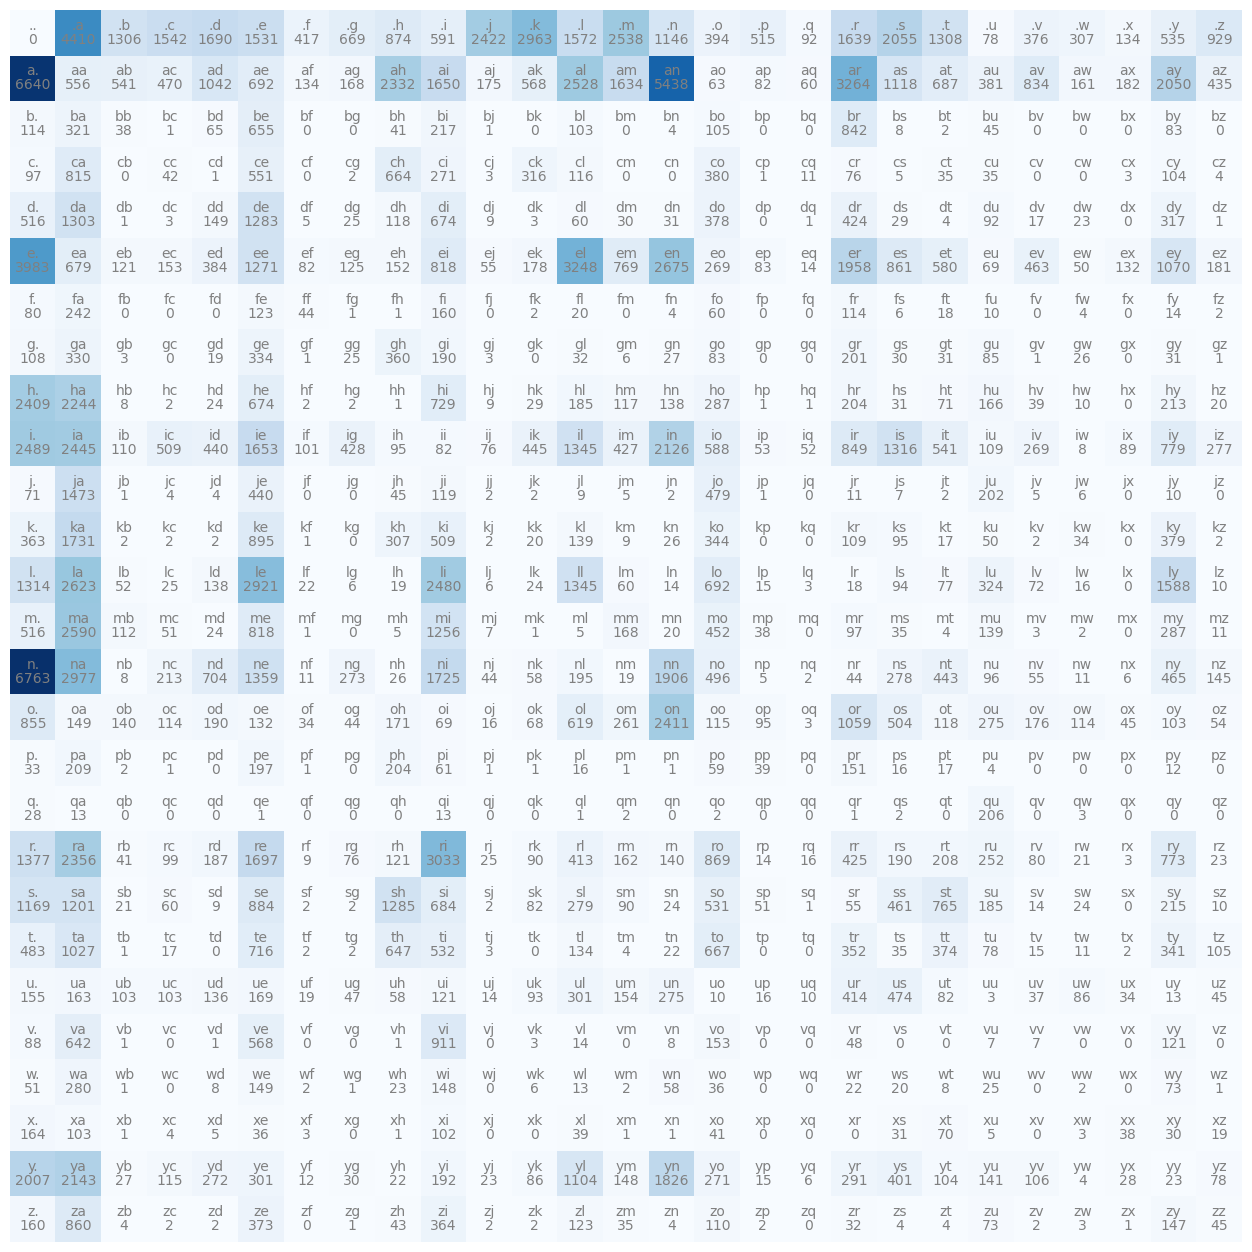

In [4]:
# 3. Training

for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    N[ix1, ix2] += 1


# normalizing the entire bigram count matrix to get the probability distribution for each row
P = (N+1).float() # N is the bigram count matrix, adding 1 to each count for add-one smoothing to avoid zero probabilities, converting to float for normalization
#  if that zero-probability bigram appears in evaluation, the log probability becomes negative infinity, which makes the loss blow up.
P = P / P.sum(1, keepdims=True) # normalizing each row; sums across each column(dim = 1); keepdims=True for making broadcasting works in column-wise division

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off')
plt.show()



In [5]:
# 4. Evaluation

log_likelihood = 0.0
n = 0

for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2] # treat it as the true label
    prob = P[ix1, ix2] # it is the probability of predicting true label given the first one (higher is better) 
    logprob = torch.log(prob)
    log_likelihood += logprob
    n += 1

nll = -log_likelihood / n
print(f'loss = {nll}')

loss = 2.4543561935424805


In [6]:
# 4. Inference

torch.manual_seed(42)
for i in range(5):
  out = []
  ix = 0
  
  while True:
    p = P[ix]

    ix = torch.multinomial(p, num_samples=1, replacement=True).item() # note that it get replace by new char
    out.append(itos[ix])
    if ix == 0:
      break
    
  print(''.join(out))

anugeenvi.
s.
mabidushan.
stan.
silaylelaremah.


# 2. Trigram Model

In [7]:
# 1. Data Preprocessing

# reading the file and splitting it into the list "words"
# words = open('../data/names.txt', 'r').read().splitlines() # in case of local file
url = "https://raw.githubusercontent.com/yahya94812/Neural-Language-Modeling/refs/heads/main/data/names.txt"
words = urlopen(url).read().decode("utf-8").splitlines()
print(len(words))
print(min(len(w) for w in words))
print(max(len(w) for w in words))
print(words[:10])

chars = sorted(list(set(''.join(words)))) # unique characters in the dataset
stoi = {s:i+1 for i,s in enumerate(chars)}  # stoi(mapping): string to integer mapping based on index
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}


32033
2
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn']


In [8]:
# 2. Defining The Model

N = torch.zeros((27, 27, 27), dtype=torch.int32)


In [9]:
# 3. Training

for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2, ch3 in zip(chs, chs[1:], chs[2:]):
    ix1 = stoi[ch1] # ix1 is in height dim
    ix2 = stoi[ch2] # ix2 is in row dim
    ix3 = stoi[ch3] # ix3 is in column dim
    N[ix1, ix2, ix3] += 1

N = (N + 1).float() # to prevent inf loss value in evaluation
P = N / N.sum(-1, keepdim=True) # getting probabilities 


In [10]:
# 4. Evaluation

log_likelihood = 0.0
n = 0

for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2, ch3 in zip(chs, chs[1:], chs[2:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    ix3 = stoi[ch3] # treat it as the true label
    prob = P[ix1, ix2, ix3] # it is the probability of predicting true label given the first two (higher is better) 
    logprob = torch.log(prob)
    log_likelihood += logprob
    n += 1

nll = -log_likelihood / n
print(f'loss = {nll}')


loss = 2.092747449874878


In [11]:
# Inference

torch.manual_seed(42)
for i in range(5): # generating 5 samples
  out = [] # used it to store char of each sample flush on next sample 
  ix1 = 0 # given first char
  ix2 = 0 # given second char (required for trigram)
  
  while True:
    ix3 = torch.multinomial(P[ix1, ix2], num_samples=1, replacement=True).item() # note that it get replace by new char
    out.append(itos[ix3])
    ix1 = ix2
    ix2 = ix3
    
    if ix3 == 0:
      break
    
  print(''.join(out))
  

xauguelvtps.
fabidushante.
na.
silayley.
otmah.
